In [1]:
from DatasetLoading import RepairDatasetLoader
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import lightning as L
import torch
from lightning.pytorch.loggers import WandbLogger
import os

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from GridReconstruction import GridReconstructionNetwork
from GridReconstruction import GridReconstruction
from NerfRepresentationUtils import plot_colored_voxels
from NerfRepresentationUtils import plot_opacity_tensor
import torch.nn.functional as F

torch.set_float32_matmul_precision('medium')

In [2]:
dataset_loader = RepairDatasetLoader(batch_size=2, dataset_type="FixedGridDataset",
                                         representation_folder_name="grids", num_workers=2)

In [3]:
lightning_model = GridReconstruction.load_from_checkpoint("GridReconstruction1.ckpt")
model = lightning_model.model
model.eval()
model = model.cpu()

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0


In [4]:
model

GridReconstructionNetwork(
  (encoder): Sequential(
    (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (8): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (12): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPo

In [5]:
test_dataset = dataset_loader.test_dataloader().dataset

In [6]:
representation, idx_tensors, vals_tensor, colour_tensor, directions = test_dataset.get_testing_items(2)

In [7]:
test_dataset.piece_names[2]

'RPf_00206.npz'

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

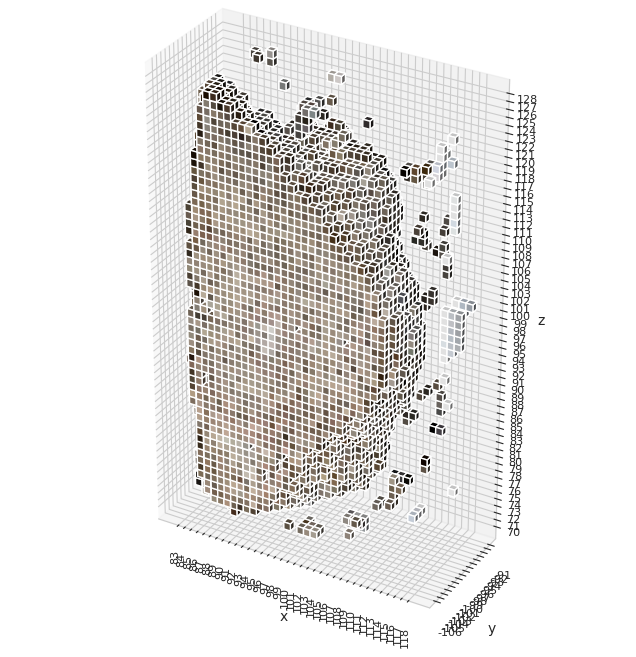

In [8]:
plot_colored_voxels(idx_tensors, colour_tensor)

In [9]:
reconstructed_grid = model(representation.unsqueeze(0)).squeeze(0)

In [10]:
weights = reconstructed_grid[-1]

In [11]:
weights.shape

torch.Size([200, 200, 200])

In [12]:
r_idx_tensors = torch.where(weights > 0.3)

In [13]:
r_idx_tensors[0].shape[0]

6777

In [14]:
random_directions = F.normalize(torch.randn((r_idx_tensors[0].shape[0], 3)), p=2, dim=1)
latent = reconstructed_grid[:-1, r_idx_tensors[0], r_idx_tensors[1], r_idx_tensors[2]].T


In [15]:
latent.shape

torch.Size([6777, 31])

In [16]:
r_colours = test_dataset.latent2representation.get_colour_from_latent(latent, random_directions).detach()

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

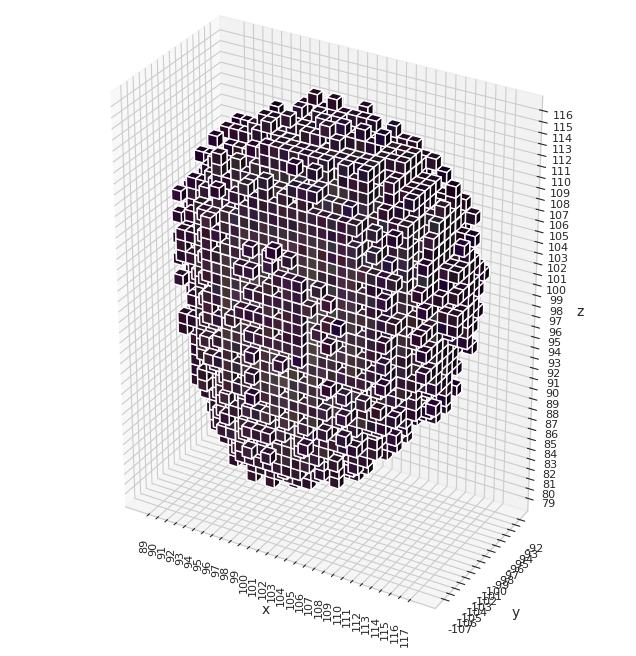

In [17]:
plot_colored_voxels(r_idx_tensors, r_colours)

59


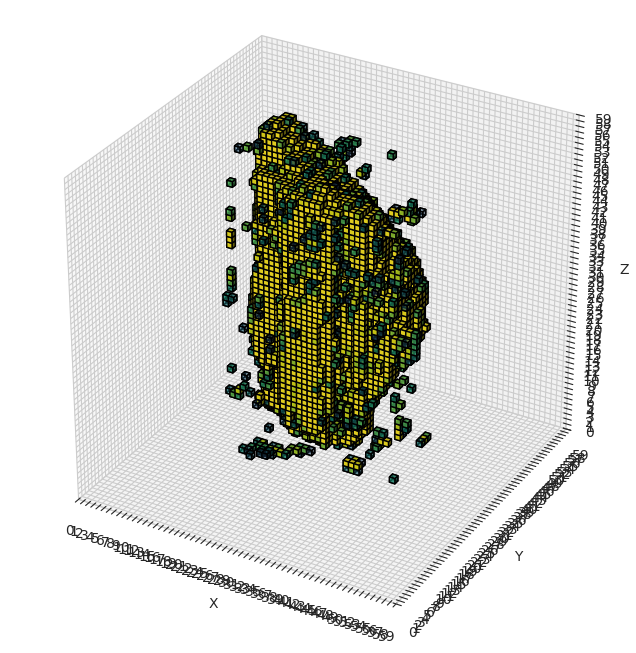

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(71, 130, None), slice(69, 128, None), slice(70, 129, None)))

In [17]:
plot_opacity_tensor(representation[-1], threshold=0.3)

46


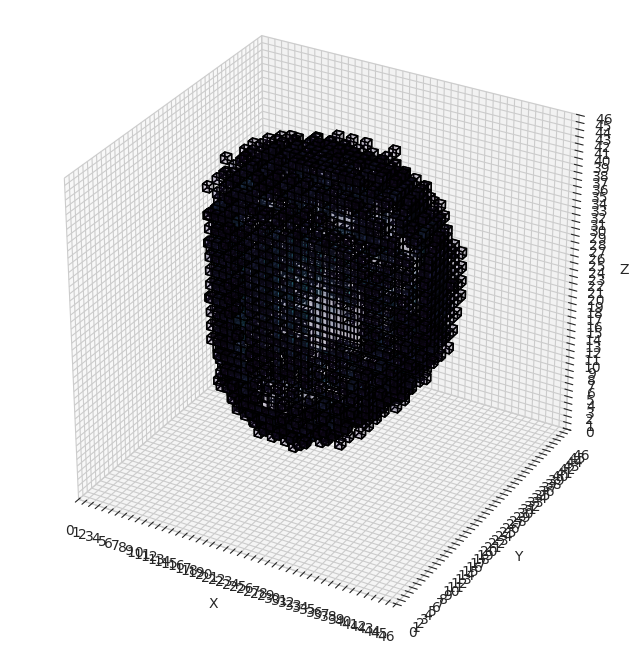

(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>,
 (slice(80, 126, None), slice(77, 123, None), slice(73, 119, None)))

In [21]:
plot_opacity_tensor(reconstructed_grid[-1], threshold=0.1)


In [28]:
convTest = nn.ConvTranspose3d(in_channels=1, out_channels=1, kernel_size=4, stride=2, padding=13)

In [29]:
convTest(torch.zeros(1, 1, 112, 112, 112)).shape

torch.Size([1, 1, 200, 200, 200])